In [5]:
import os
import shutil

src = './data/JPEGImages'
dst = './data/ACNE04'

# 4 класс папкасын жасау
for level in range(4):
    os.makedirs(f'{dst}/level_{level}', exist_ok=True)

# Файлдарды бөлу
for filename in os.listdir(src):
    if filename.endswith('.jpg'):
        for level in range(4):
            if f'levle{level}' in filename:
                shutil.copy(
                    os.path.join(src, filename),
                    os.path.join(dst, f'level_{level}', filename)
                )

# Нәтижені тексеру
for level in range(4):
    count = len(os.listdir(f'{dst}/level_{level}'))
    print(f'Level {level}: {count} сурет')

Level 0: 497 сурет
Level 1: 637 сурет
Level 2: 186 сурет
Level 3: 137 сурет


In [6]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

# Трансформациялар
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Датасет жүктеу
full_dataset = datasets.ImageFolder(
    root='./data/ACNE04',
    transform=train_transforms
)

print("Класстар:", full_dataset.classes)
print("Жалпы сурет:", len(full_dataset))

# 70% train, 15% val, 15% test
total = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# val/test үшін transform ауыстыру
val_ds.dataset.transform   = val_transforms
test_ds.dataset.transform  = val_transforms

# DataLoader
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

print(f"\nTrain: {train_size} | Val: {val_size} | Test: {test_size}")

Класстар: ['level_0', 'level_1', 'level_2', 'level_3']
Жалпы сурет: 1457

Train: 1019 | Val: 218 | Test: 220


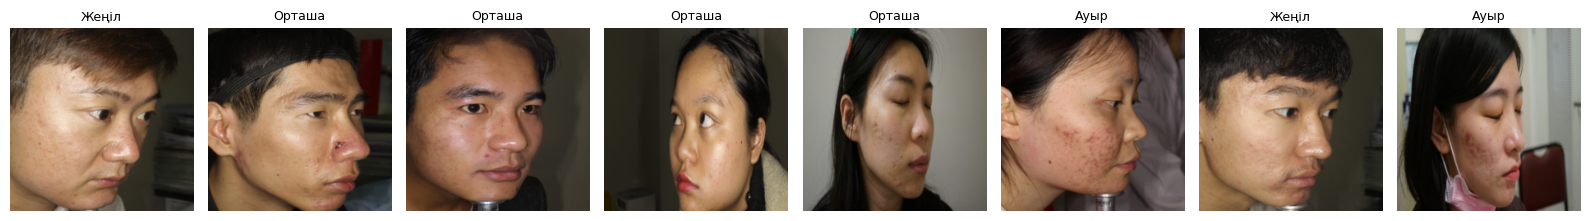

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def show_samples(dataset, n=8):
    fig, axes = plt.subplots(1, n, figsize=(16, 3))
    class_names = ['Жеңіл', 'Орташа', 'Ауыр', 'Өте ауыр']
    
    for i in range(n):
        img, label = dataset[i]
        # Normalize кері қайтару
        img = img * torch.tensor([0.229, 0.224, 0.225])[:,None,None]
        img = img + torch.tensor([0.485, 0.456, 0.406])[:,None,None]
        img = img.permute(1, 2, 0).clamp(0, 1).numpy()
        
        axes[i].imshow(img)
        axes[i].set_title(class_names[label], fontsize=9)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

show_samples(train_ds)

In [8]:
import torch
import torch.nn as nn
from torchvision import models

# M1 GPU
device = torch.device("mps")

# ResNet-50 — ImageNet weights-пен
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Соңғы қабатты 4 класқа өзгерту
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 4)
)

model = model.to(device)

# Модель параметрлерін тексеру
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Жалпы параметр: {total_params:,}")
print(f"Үйренетін параметр: {trainable_params:,}")
print(f"Құрылғы: {device}")
print("Модель дайын ✓")

Жалпы параметр: 23,516,228
Үйренетін параметр: 23,516,228
Құрылғы: mps
Модель дайын ✓


In [9]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

# Тренинг функциясы
def train_model(model, train_loader, val_loader, epochs=15):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = correct / total * 100

        # --- Validation ---
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc  = correct / total * 100

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Best model сақтау
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"Epoch {epoch+1:2d} | Train: {train_acc:.1f}% | Val: {val_acc:.1f}% ⭐ сақталды")
        else:
            print(f"Epoch {epoch+1:2d} | Train: {train_acc:.1f}% | Val: {val_acc:.1f}%")

        scheduler.step()

    return train_losses, val_losses, train_accs, val_accs

# Тренинг бастау
print("Тренинг басталды...\n")
history = train_model(model, train_loader, val_loader, epochs=15)
print(f"\nТренинг аяқталды!")

Тренинг басталды...

Epoch  1 | Train: 44.8% | Val: 59.6% ⭐ сақталды
Epoch  2 | Train: 72.4% | Val: 65.6% ⭐ сақталды
Epoch  3 | Train: 90.7% | Val: 70.6% ⭐ сақталды
Epoch  4 | Train: 96.1% | Val: 67.4%
Epoch  5 | Train: 96.7% | Val: 67.0%
Epoch  6 | Train: 98.5% | Val: 71.6% ⭐ сақталды
Epoch  7 | Train: 98.6% | Val: 72.9% ⭐ сақталды
Epoch  8 | Train: 99.2% | Val: 72.5%
Epoch  9 | Train: 99.2% | Val: 71.6%
Epoch 10 | Train: 99.1% | Val: 73.4% ⭐ сақталды
Epoch 11 | Train: 99.2% | Val: 71.6%
Epoch 12 | Train: 99.4% | Val: 69.3%
Epoch 13 | Train: 99.6% | Val: 72.0%
Epoch 14 | Train: 99.5% | Val: 70.2%
Epoch 15 | Train: 99.3% | Val: 71.6%

Тренинг аяқталды!


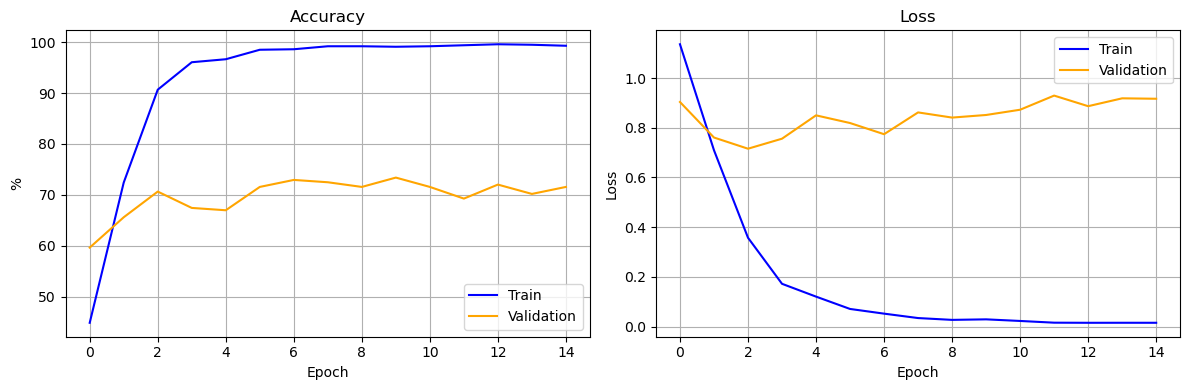

График сақталды ✓


In [10]:
import matplotlib.pyplot as plt

train_losses, val_losses, train_accs, val_accs = history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy графигі
ax1.plot(train_accs, label='Train', color='blue')
ax1.plot(val_accs, label='Validation', color='orange')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('%')
ax1.legend()
ax1.grid(True)

# Loss графигі
ax2.plot(train_losses, label='Train', color='blue')
ax2.plot(val_losses, label='Validation', color='orange')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()
print("График сақталды ✓")

              precision    recall  f1-score   support

     Level 0       0.75      0.86      0.80        71
     Level 1       0.76      0.72      0.74       101
     Level 2       0.62      0.48      0.55        31
     Level 3       0.79      0.88      0.83        17

    accuracy                           0.75       220
   macro avg       0.73      0.74      0.73       220
weighted avg       0.74      0.75      0.74       220



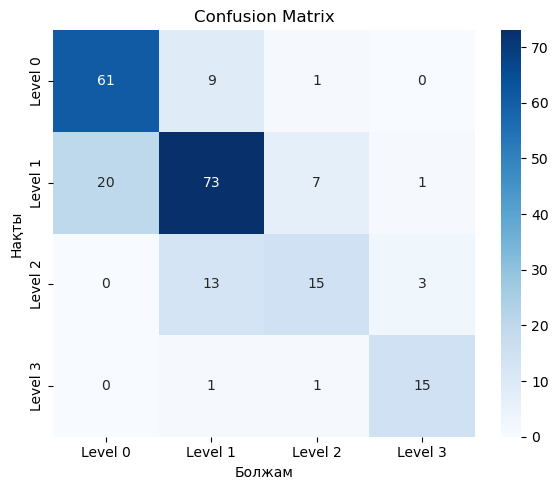

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Best model жүктеу
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = ['Level 0', 'Level 1', 'Level 2', 'Level 3']

# Classification report
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Нақты')
plt.xlabel('Болжам')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

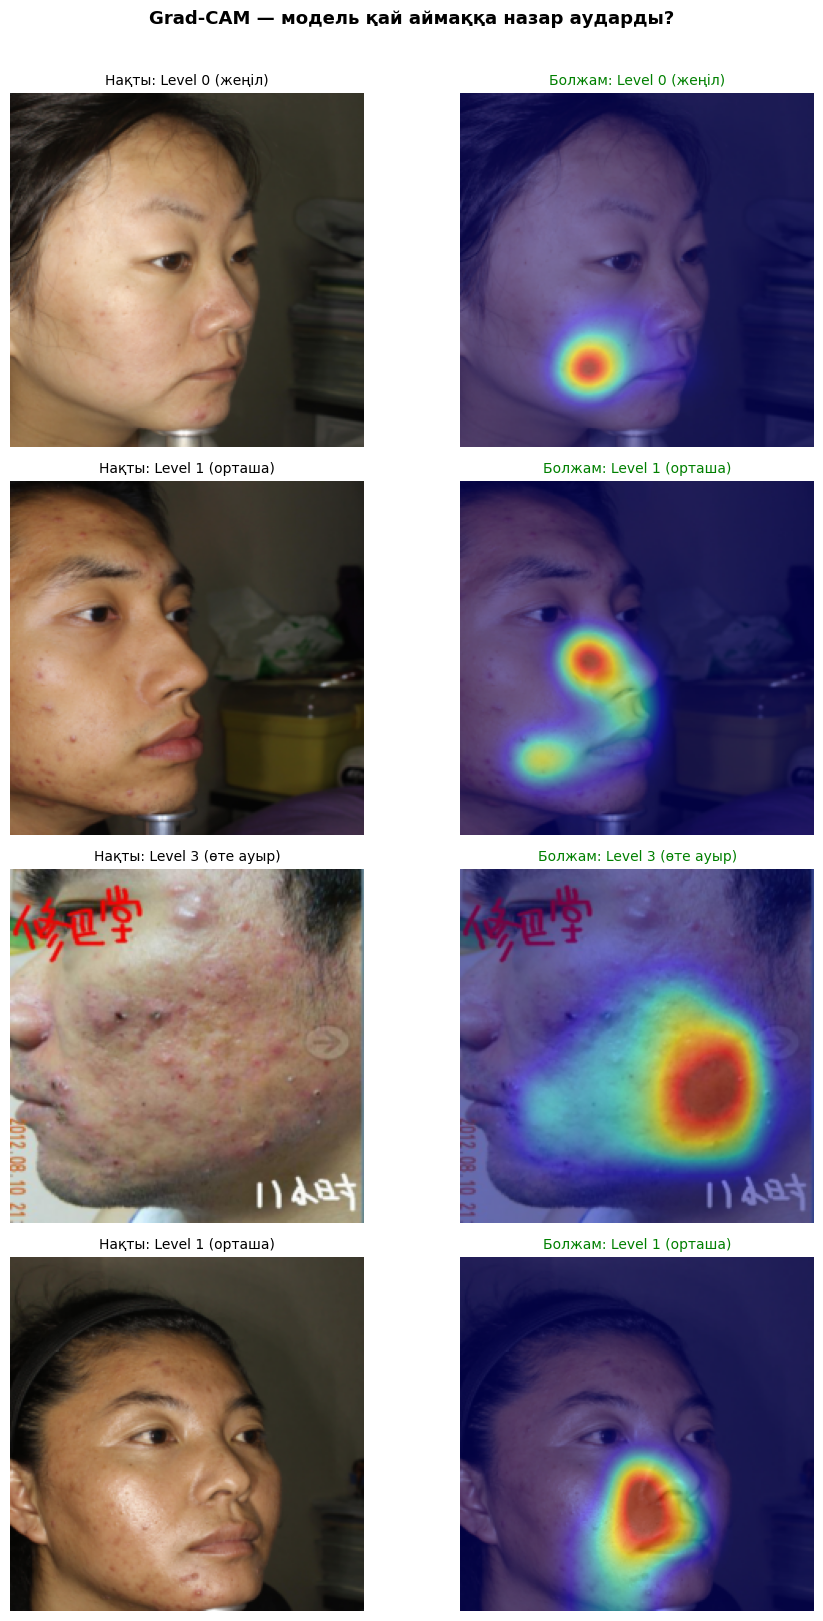

Grad-CAM визуализациясы дайын ✓


In [12]:
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt
import torch
import numpy as np

# Best model жүктеу
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

# Grad-CAM — соңғы conv қабатына қосу
cam_extractor = GradCAM(model, target_layer='layer4')

class_names = ['Level 0 (жеңіл)', 'Level 1 (орташа)', 
               'Level 2 (ауыр)', 'Level 3 (өте ауыр)']

# Test деректерінен 4 сурет алып визуализациялау
fig, axes = plt.subplots(4, 2, figsize=(10, 16))

count = 0
for imgs, labels in test_loader:
    if count >= 4:
        break
    
    img = imgs[0:1].to(device)
    label = labels[0].item()
    
    # Болжам
    with torch.enable_grad():
        output = model(img)
        pred = output.argmax().item()
        
        # Grad-CAM карта
        activation_map = cam_extractor(pred, output)
    
    # Визуализация
    img_pil = to_pil_image(imgs[0] * torch.tensor([0.229, 0.224, 0.225])[:,None,None] 
                           + torch.tensor([0.485, 0.456, 0.406])[:,None,None])
    
    result = overlay_mask(img_pil, to_pil_image(activation_map[0].squeeze(0), mode='F'), alpha=0.5)
    
    # Оригинал сурет
    axes[count, 0].imshow(img_pil)
    axes[count, 0].set_title(f'Нақты: {class_names[label]}', fontsize=10)
    axes[count, 0].axis('off')
    
    # Grad-CAM heatmap
    axes[count, 1].imshow(result)
    color = 'green' if pred == label else 'red'
    axes[count, 1].set_title(f'Болжам: {class_names[pred]}', 
                              fontsize=10, color=color)
    axes[count, 1].axis('off')
    
    count += 1
    imgs_next = imgs[1:]
    labels_next = labels[1:]

plt.suptitle('Grad-CAM — модель қай аймаққа назар аударды?', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM визуализациясы дайын ✓")

In [3]:
import torch
import torch.nn as nn
from torchvision import transforms, models

device = torch.device("mps")

# Transforms
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Model
model = models.resnet50(weights=None)
num_features = model.fc.in_features
model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(num_features, 4))
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model = model.to(device)
model.eval()

print("Model дайын ✓")

Model дайын ✓


In [4]:
import gradio as gr
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image
from PIL import Image

class_names = ['Level 0 — жеңіл', 'Level 1 — орташа', 
               'Level 2 — ауыр', 'Level 3 — өте ауыр']

def predict(image):
    img_tensor = val_transforms(image).unsqueeze(0).to(device)
    
    cam_extractor = GradCAM(model, target_layer='layer4')
    
    with torch.enable_grad():
        output = model(img_tensor)
        pred = output.argmax().item()
        probs = torch.softmax(output, dim=1)[0]
        activation_map = cam_extractor(pred, output)
    
    confidences = {class_names[i]: float(probs[i]) for i in range(4)}
    
    img_pil = image.resize((224, 224))
    result = overlay_mask(
        img_pil, 
        to_pil_image(activation_map[0].squeeze(0), mode='F'), 
        alpha=0.5
    )
    
    return result, confidences

with gr.Blocks() as demo:
    gr.Markdown("# 🔬 Acne Severity Detection with Grad-CAM")
    gr.Markdown("Бет суретін жүктеңіз — модель акне деңгейін анықтап, қай аймаққа назар аударғанын көрсетеді.")
    
    with gr.Row():
        input_img = gr.Image(type='pil', label='Бет суретін жүктеңіз')
    
    submit_btn = gr.Button("Анықтау", variant="primary")
    
    with gr.Row():
        output_img = gr.Image(label='Grad-CAM нәтижесі')
        output_label = gr.Label(label='Акне деңгейі', num_top_classes=4)
    
    submit_btn.click(
        fn=predict,
        inputs=input_img,
        outputs=[output_img, output_label]
    )

demo.launch(share=False, theme=gr.themes.Soft(
    primary_hue="purple",
    secondary_hue="pink",
    neutral_hue="slate"
))

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


/var/folders/d3/9y_8f_xj7q77m2pqqx9c30xh0000gn/T/ipykernel_11724/3066018996.py:21: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  confidences = {class_names[i]: float(probs[i]) for i in range(4)}
